# PDPTW Walkthrough

**Pickup and Delivery Problem with Time Windows.** Same fleet, same time windows, same capacity — but customers now come in **pairs**. Each request has a *pickup* node and a *delivery* node, and three constraints bind them together:

1. **Same vehicle.** The vehicle that picks the freight up must be the one that drops it off.
2. **Precedence.** The pickup must happen *before* the delivery on that route.
3. **Signed demand.** Pickup adds load to the vehicle; delivery removes it. The capacity dimension's cumul value naturally tracks the current load.

## What's new in the OR-Tools API

Three methods, all called once per request:

- `routing.AddPickupAndDelivery(p_idx, d_idx)` — tells OR-Tools these two indices are a pair.
- `routing.solver().Add(routing.VehicleVar(p_idx) == routing.VehicleVar(d_idx))` — forces both onto the same vehicle.
- `routing.solver().Add(time_dim.CumulVar(p_idx) <= time_dim.CumulVar(d_idx))` — pickup time ≤ delivery time, which (combined with the same-vehicle constraint) is precedence.

Demand modelling is also slightly different: each pickup has demand `+q`, each delivery has demand `-q`, depot has 0. The capacity dimension already supports this natively — no extra setup.

In [1]:
%load_ext autoreload
%autoreload 2

import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

random.seed(31)
np.random.seed(31)

## 1. An instance with pickup-delivery requests

Think *parcel logistics*: 5 packages need to be picked up at one address and dropped off at another, all in one working day, with the same small fleet.

- Depot at the centre of a 50×50 km square.
- 5 requests, each = (pickup location, delivery location, quantity).
- Pickup window: 90 min wide, scattered through the morning/early afternoon.
- Delivery window: 180 min wide, starts when the pickup window ends — so the natural pickup-before-delivery flow is at least feasible.
- 2 vehicles, capacity 6, working day 480 min, 5-minute service per stop.

In [2]:
N_REQUESTS = 5
DEPOT = 0
HORIZON = 480
SERVICE_TIME = 5
NUM_VEHICLES = 2
VEHICLE_CAPACITY = 6

# Build the node list: depot first, then pickup_i, delivery_i for each request.
points = [(25.0, 25.0)]
demands = [0]
windows = [(0, HORIZON)]
labels = ["depot"]
pairs = []   # (pickup_node, delivery_node)
quantities = []

for i in range(N_REQUESTS):
    p = (random.uniform(5, 45), random.uniform(5, 45))
    d = (random.uniform(5, 45), random.uniform(5, 45))
    q = random.randint(1, 3)
    pickup_start = random.randint(30, 240)

    points.append(p)
    demands.append(+q)
    windows.append((pickup_start, pickup_start + 90))
    labels.append(f"P{i}")
    pickup_node = len(points) - 1

    points.append(d)
    demands.append(-q)
    delivery_start = pickup_start + 90
    windows.append((delivery_start, delivery_start + 180))
    labels.append(f"D{i}")
    delivery_node = len(points) - 1

    pairs.append((pickup_node, delivery_node))
    quantities.append(q)


def make_int_distance(pts):
    n = len(pts)
    m = [[0] * n for _ in range(n)]
    for i, (xi, yi) in enumerate(pts):
        for j, (xj, yj) in enumerate(pts):
            if i != j:
                m[i][j] = int(round(math.hypot(xi - xj, yi - yj)))
    return m

distance = make_int_distance(points)

print(f"{N_REQUESTS} requests, total freight moved: {sum(quantities)}")
for i, ((pn, dn), q) in enumerate(zip(pairs, quantities)):
    print(f"  req {i}: pickup node {pn} (window {windows[pn]}), delivery node {dn} (window {windows[dn]}), q={q}")

5 requests, total freight moved: 5
  req 0: pickup node 1 (window (58, 148)), delivery node 2 (window (148, 328)), q=1
  req 1: pickup node 3 (window (199, 289)), delivery node 4 (window (289, 469)), q=1
  req 2: pickup node 5 (window (181, 271)), delivery node 6 (window (271, 451)), q=1
  req 3: pickup node 7 (window (82, 172)), delivery node 8 (window (172, 352)), q=1
  req 4: pickup node 9 (window (136, 226)), delivery node 10 (window (226, 406)), q=1


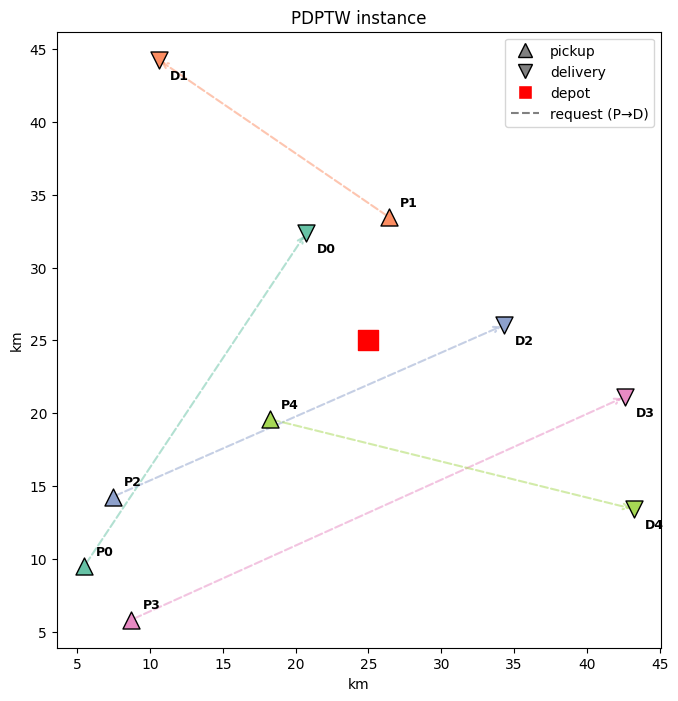

In [3]:
def plot_instance(points, pairs, labels, title="PDPTW instance"):
    fig, ax = plt.subplots(figsize=(8, 8))
    request_colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(pairs))))
    for i, (pn, dn) in enumerate(pairs):
        # Faint arrow from pickup to delivery
        ax.annotate("", xy=points[dn], xytext=points[pn],
                    arrowprops=dict(arrowstyle="->", color=request_colors[i],
                                    lw=1.5, linestyle="dashed", alpha=0.5))
        ax.scatter(*points[pn], marker="^", s=150, color=request_colors[i],
                   edgecolors="black", zorder=5)
        ax.scatter(*points[dn], marker="v", s=150, color=request_colors[i],
                   edgecolors="black", zorder=5)
        ax.annotate(labels[pn], points[pn], textcoords="offset points",
                    xytext=(8, 8), fontsize=9, fontweight="bold")
        ax.annotate(labels[dn], points[dn], textcoords="offset points",
                    xytext=(8, -14), fontsize=9, fontweight="bold")
    ax.scatter(*points[0], c="red", s=200, marker="s", zorder=6, label="depot")
    ax.set_aspect("equal"); ax.set_title(title)
    ax.set_xlabel("km"); ax.set_ylabel("km")
    # Custom legend
    from matplotlib.lines import Line2D
    leg = [
        Line2D([0], [0], marker="^", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=10, label="pickup"),
        Line2D([0], [0], marker="v", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=10, label="delivery"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="red",
               markersize=10, label="depot"),
        Line2D([0], [0], linestyle="dashed", color="gray", label="request (P\u2192D)"),
    ]
    ax.legend(handles=leg, loc="upper right")
    plt.show()

plot_instance(points, pairs, labels)

## 2. Building the PDPTW model

Same skeleton as VRPTW: capacity dimension, time dimension, time windows. The new code is one loop at the bottom registering each request's three constraints (`AddPickupAndDelivery`, same-vehicle, time precedence).

Note that the demand callback returns **signed** values: positive at pickups, negative at deliveries, zero at the depot. The capacity dimension's cumul variable is therefore the *current load* at each stop, not the cumulative pickup volume. As long as this current load stays in `[0, capacity]`, we're good.

In [4]:
def build_pdptw_model(
    distance, demands, time_windows, pairs, capacities,
    service_time, horizon, depot=0, wait_slack=60,
):
    n = len(distance)
    num_vehicles = len(capacities)
    manager = pywrapcp.RoutingIndexManager(n, num_vehicles, depot)
    routing = pywrapcp.RoutingModel(manager)

    def distance_cb(fi, ti):
        return distance[manager.IndexToNode(fi)][manager.IndexToNode(ti)]
    transit_idx = routing.RegisterTransitCallback(distance_cb)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

    def demand_cb(fi):
        return demands[manager.IndexToNode(fi)]
    demand_idx = routing.RegisterUnaryTransitCallback(demand_cb)
    routing.AddDimensionWithVehicleCapacity(
        demand_idx, 0, list(capacities), True, "Capacity",
    )

    def time_cb(fi, ti):
        from_node = manager.IndexToNode(fi)
        to_node = manager.IndexToNode(ti)
        st = 0 if from_node == depot else service_time
        return st + distance[from_node][to_node]
    time_idx = routing.RegisterTransitCallback(time_cb)
    routing.AddDimension(time_idx, wait_slack, horizon, False, "Time")
    time_dim = routing.GetDimensionOrDie("Time")

    for node in range(n):
        if node == depot:
            continue
        a, b = time_windows[node]
        time_dim.CumulVar(manager.NodeToIndex(node)).SetRange(int(a), int(b))

    depot_open, depot_close = time_windows[depot]
    for v in range(num_vehicles):
        time_dim.CumulVar(routing.Start(v)).SetRange(int(depot_open), int(depot_close))
        time_dim.CumulVar(routing.End(v)).SetRange(int(depot_open), int(depot_close))
        routing.AddVariableMinimizedByFinalizer(time_dim.CumulVar(routing.Start(v)))
        routing.AddVariableMinimizedByFinalizer(time_dim.CumulVar(routing.End(v)))

    # The new bit: pickup-delivery pairs.
    for pickup_node, delivery_node in pairs:
        p_idx = manager.NodeToIndex(pickup_node)
        d_idx = manager.NodeToIndex(delivery_node)
        routing.AddPickupAndDelivery(p_idx, d_idx)
        routing.solver().Add(routing.VehicleVar(p_idx) == routing.VehicleVar(d_idx))
        routing.solver().Add(time_dim.CumulVar(p_idx) <= time_dim.CumulVar(d_idx))

    return manager, routing, time_dim


def solve(routing, time_limit=10):
    params = pywrapcp.DefaultRoutingSearchParameters()
    # PARALLEL_CHEAPEST_INSERTION handles pickup-delivery pairs better than PATH_CHEAPEST_ARC.
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(time_limit)
    return routing.SolveWithParameters(params)


manager, routing, time_dim = build_pdptw_model(
    distance, demands, windows, pairs,
    capacities=[VEHICLE_CAPACITY] * NUM_VEHICLES,
    service_time=SERVICE_TIME, horizon=HORIZON,
)
solution = solve(routing, time_limit=10)
print("Status:", routing.status(), " Total distance:", solution.ObjectiveValue(), "km")

Status: 1  Total distance: 148 km


## 3. Walking the routes

Print each vehicle's stops in order, showing whether each visit is a pickup (load goes up) or delivery (load goes down), plus the running load along the route. The expected pattern: load is non-negative throughout, capped at the vehicle's capacity, and ends back at zero before returning to the depot.

In [5]:
capacity_dim = routing.GetDimensionOrDie("Capacity")

routes = []
for v in range(NUM_VEHICLES):
    idx = routing.Start(v)
    route_nodes = [manager.IndexToNode(idx)]
    while not routing.IsEnd(idx):
        idx = solution.Value(routing.NextVar(idx))
        route_nodes.append(manager.IndexToNode(idx))

    if len(route_nodes) <= 2:
        print(f"\nvehicle {v}: --- unused ---")
        routes.append(route_nodes)
        continue

    print(f"\nvehicle {v}:")
    idx = routing.Start(v)
    while not routing.IsEnd(idx):
        node = manager.IndexToNode(idx)
        arrive = solution.Min(time_dim.CumulVar(idx))
        load_at = solution.Value(capacity_dim.CumulVar(idx))
        kind = "depot   " if node == DEPOT else ("PICKUP  " if demands[node] > 0 else "DELIVERY")
        win = windows[node]
        print(f"  {kind} {labels[node]:>5s}  arrive@{arrive:>3d}  load={load_at}/{VEHICLE_CAPACITY}  window=[{win[0]:>3d},{win[1]:>3d}]")
        idx = solution.Value(routing.NextVar(idx))
    end_node = manager.IndexToNode(idx)
    end_time = solution.Min(time_dim.CumulVar(idx))
    end_load = solution.Value(capacity_dim.CumulVar(idx))
    print(f"  depot    {labels[end_node]:>5s}  arrive@{end_time:>3d}  load={end_load}/{VEHICLE_CAPACITY}")
    routes.append(route_nodes)


vehicle 0: --- unused ---

vehicle 1:
  depot    depot  arrive@  0  load=0/6  window=[  0,480]
  PICKUP      P3  arrive@ 82  load=0/6  window=[ 82,172]
  PICKUP      P0  arrive@111  load=1/6  window=[ 58,148]
  PICKUP      P2  arrive@181  load=2/6  window=[181,271]
  PICKUP      P4  arrive@198  load=3/6  window=[136,226]
  DELIVERY    D4  arrive@229  load=4/6  window=[226,406]
  DELIVERY    D3  arrive@242  load=3/6  window=[172,352]
  DELIVERY    D2  arrive@271  load=2/6  window=[271,451]
  PICKUP      P1  arrive@287  load=1/6  window=[199,289]
  DELIVERY    D0  arrive@298  load=2/6  window=[148,328]
  DELIVERY    D1  arrive@319  load=1/6  window=[289,469]
  depot    depot  arrive@348  load=0/6


Let's also explicitly verify the three pickup-delivery constraints — they're easy to take for granted but worth a sanity check the first time you see them in action.

In [6]:
def vehicle_of(node, routes):
    for v, r in enumerate(routes):
        if node in r and node != DEPOT:
            return v
    return None

def position_in_route(node, route):
    return route.index(node)

ok = True
for i, (p_node, d_node) in enumerate(pairs):
    v_p = vehicle_of(p_node, routes)
    v_d = vehicle_of(d_node, routes)
    same_vehicle = v_p == v_d
    if not same_vehicle:
        ok = False
        print(f"req {i}: VIOLATION pickup on v{v_p}, delivery on v{v_d}")
        continue
    pos_p = position_in_route(p_node, routes[v_p])
    pos_d = position_in_route(d_node, routes[v_p])
    precedence = pos_p < pos_d
    if not precedence:
        ok = False
        print(f"req {i}: VIOLATION pickup at position {pos_p}, delivery at {pos_d} (delivery before pickup!)")
        continue
    print(f"req {i}: OK   vehicle v{v_p}, pickup at position {pos_p}, delivery at {pos_d}")

print("\nAll constraints satisfied:", ok)

req 0: OK   vehicle v1, pickup at position 2, delivery at 9
req 1: OK   vehicle v1, pickup at position 8, delivery at 10
req 2: OK   vehicle v1, pickup at position 3, delivery at 7
req 3: OK   vehicle v1, pickup at position 1, delivery at 6
req 4: OK   vehicle v1, pickup at position 4, delivery at 5

All constraints satisfied: True


## 4. Visualising routes and freight flow

Two annotations layered on the geographic plot:

- **Dashed coloured arrows** = the requests themselves (where freight needs to *go*).
- **Solid coloured lines** = the actual vehicle routes (the order stops are visited).

The interesting cases are when a vehicle picks up multiple parcels before dropping any of them off — the solid route line will cross several dashed request arrows.

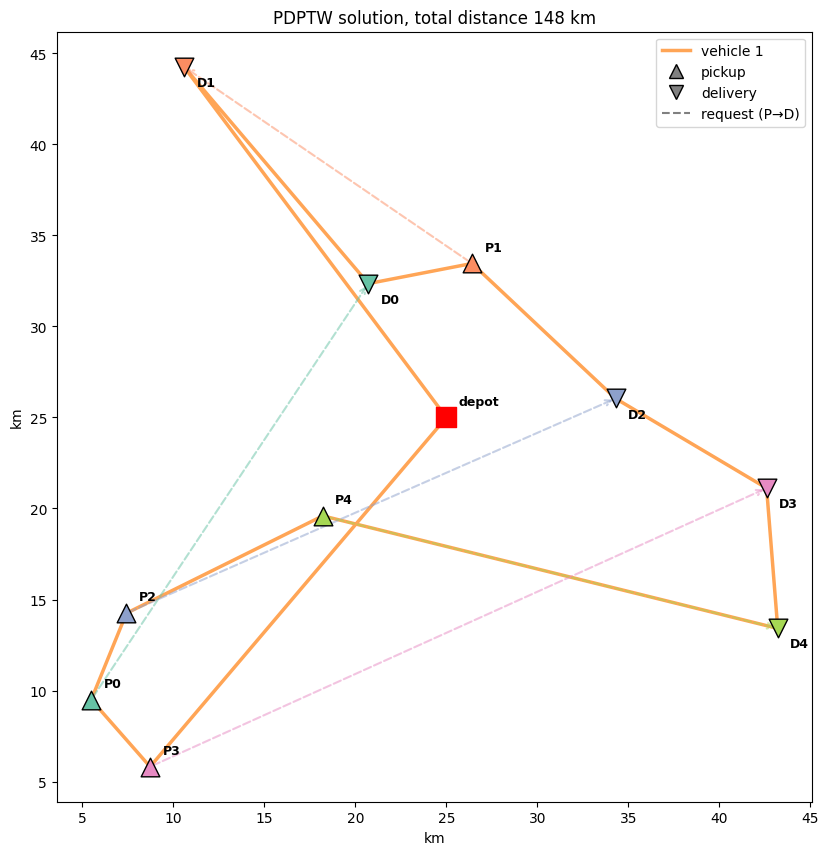

In [7]:
def plot_pdptw(points, pairs, routes, labels, num_vehicles, title=""):
    from matplotlib.lines import Line2D
    fig, ax = plt.subplots(figsize=(10, 10))
    vehicle_colors = plt.cm.tab10(np.linspace(0, 1, max(10, num_vehicles)))
    request_colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(pairs))))

    for i, (pn, dn) in enumerate(pairs):
        ax.annotate("", xy=points[dn], xytext=points[pn],
                    arrowprops=dict(arrowstyle="->", color=request_colors[i],
                                    lw=1.5, linestyle="dashed", alpha=0.5))

    for v, route in enumerate(routes):
        if len(route) <= 2:
            continue
        rx = [points[i][0] for i in route]
        ry = [points[i][1] for i in route]
        ax.plot(rx, ry, "-", color=vehicle_colors[v], linewidth=2.5, alpha=0.7,
                label=f"vehicle {v}")

    for i, (pn, dn) in enumerate(pairs):
        ax.scatter(*points[pn], marker="^", s=180, color=request_colors[i],
                   edgecolors="black", zorder=5)
        ax.scatter(*points[dn], marker="v", s=180, color=request_colors[i],
                   edgecolors="black", zorder=5)
        ax.annotate(labels[pn], points[pn], textcoords="offset points",
                    xytext=(9, 9), fontsize=9, fontweight="bold")
        ax.annotate(labels[dn], points[dn], textcoords="offset points",
                    xytext=(9, -14), fontsize=9, fontweight="bold")
    ax.scatter(*points[0], c="red", s=220, marker="s", zorder=6)
    ax.annotate("depot", points[0], textcoords="offset points",
                xytext=(9, 9), fontsize=9, fontweight="bold")

    extra = [
        Line2D([0], [0], marker="^", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=10, label="pickup"),
        Line2D([0], [0], marker="v", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=10, label="delivery"),
        Line2D([0], [0], linestyle="dashed", color="gray", label="request (P\u2192D)"),
    ]
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles=handles + extra, loc="upper right")
    ax.set_aspect("equal"); ax.set_title(title)
    ax.set_xlabel("km"); ax.set_ylabel("km")
    plt.show()

plot_pdptw(points, pairs, routes, labels, NUM_VEHICLES,
           title=f"PDPTW solution, total distance {solution.ObjectiveValue()} km")

## 5. How capacity reshapes the routes

In the baseline solve above, the solver picked up *all five* parcels before delivering any of them — the peak load reached 4/6, well under capacity, so one vehicle could chain everything. What happens if we tighten capacity? The solver must split the freight across vehicles, or interleave pickups with intermediate deliveries to keep load below the limit.

Below we sweep `VEHICLE_CAPACITY` from generous to tight and watch what changes: total distance, number of vehicles used, and the peak load reached.

In [8]:
def solve_at_capacity(cap, time_limit=10):
    mgr, rt, t_dim = build_pdptw_model(
        distance, demands, windows, pairs,
        capacities=[cap] * NUM_VEHICLES,
        service_time=SERVICE_TIME, horizon=HORIZON,
    )
    sol = solve(rt, time_limit=time_limit)
    if sol is None:
        return {"capacity": cap, "status": rt.status(), "objective": None,
                "vehicles_used": None, "peak_load": None}
    cap_dim = rt.GetDimensionOrDie("Capacity")
    used = 0
    peak = 0
    for v in range(NUM_VEHICLES):
        idx = rt.Start(v)
        visited_anything = False
        while not rt.IsEnd(idx):
            ld = sol.Value(cap_dim.CumulVar(idx))
            peak = max(peak, ld)
            if mgr.IndexToNode(idx) != DEPOT:
                visited_anything = True
            idx = sol.Value(rt.NextVar(idx))
        peak = max(peak, sol.Value(cap_dim.CumulVar(idx)))
        if visited_anything:
            used += 1
    return {"capacity": cap, "status": rt.status(),
            "objective": sol.ObjectiveValue(),
            "vehicles_used": used, "peak_load": peak}


rows = [solve_at_capacity(c) for c in [6, 4, 3, 2, 1]]
pd.DataFrame(rows)

,capacity,status,objective,vehicles_used,peak_load
0,6,1,148,1,4
1,4,1,148,1,4
2,3,1,175,2,3
3,2,1,203,2,2
4,1,1,290,2,1


## Where to go next

PDPTW is a real production-grade variant — couriers, dial-a-ride transit, on-demand logistics all live here. Common extensions from this baseline:

- **Multi-vehicle, larger fleet.** Same code, bigger `NUM_VEHICLES` and `pairs`.
- **Maximum ride time** per request — add a per-pair constraint like `time_dim.CumulVar(d) - time_dim.CumulVar(p) <= max_ride`.
- **Heterogeneous fleet** with capacity *and* compatibility (some vehicles can't carry certain requests).
- **Soft pickup windows** via `time_dim.SetCumulVarSoftUpperBound`.

## Promoting to `vrp_lib`

The next commit packages `build_pdptw_model` into `vrp_lib.solve_pdptw`, with the `pairs` argument doing the pickup-delivery setup. The signed-demand convention stays — pickups must be positive, deliveries negative, depot zero. Backed by a test in `tests/test_pdptw.py` that verifies same-vehicle + precedence for every pair.